<a href="https://colab.research.google.com/github/Nayab-khalid/FlyRank-AI-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nayab-khalid/FlyRank-AI-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
# ============================================================
# ML-10 — PART 1
# RANKED ACTIONS + REASON CODES
# ============================================================

# REASONING:
# This playbook ranks pages for human review rather than claiming
# that a page is guaranteed to recover.
#
# The queue uses observable content and search signals to suggest
# what should be reviewed first and why.
#
# Main actions:
# - refresh
# - expand
# - protect_and_refresh
# - ctr_review
# - engagement_review
# - monitor
#
# Reason codes explain the recommendation.
#
# The starter Random Forest result of Precision@50 = 0.740 is a
# documented result from the anonymized starter slice. It should
# not be treated as a guarantee for future or full-warehouse data.


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import os
import requests


# ============================================================
# FIND / DOWNLOAD THE STARTER CSV
# ============================================================

# Reasoning:
# The notebook may be running in Colab without the repository's
# data folder available locally.
#
# Therefore, first search the common locations.
# If the file is not found, download the official anonymized
# starter CSV from the FlyRank starter repository.

possible_paths = [
    Path("/content/data/raw/content_refresh_anonymized.csv"),
    Path("/content/FlyRank-AI-Internship/data/raw/content_refresh_anonymized.csv"),
    Path("/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"),
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("../data/raw/content_refresh_anonymized.csv"),
    Path("../../data/raw/content_refresh_anonymized.csv")
]

csv_path = None

for path in possible_paths:
    if path.exists():
        csv_path = path
        break


# ------------------------------------------------------------
# DOWNLOAD IF NOT FOUND
# ------------------------------------------------------------

if csv_path is None:

    print("Starter CSV not found locally.")
    print("Downloading official anonymized starter dataset...")

    csv_url = (
        "https://raw.githubusercontent.com/"
        "Nayab-khalid/FlyRank-AI-Internship/"
        "main/data/raw/content_refresh_anonymized.csv"
    )

    csv_path = Path("/content/content_refresh_anonymized.csv")

    response = requests.get(csv_url, timeout=60)

    if response.status_code != 200:
        raise RuntimeError(
            f"Could not download starter CSV. "
            f"HTTP status: {response.status_code}"
        )

    csv_path.write_bytes(response.content)

    print("Downloaded successfully.")


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("File:", csv_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())


# ============================================================
# CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "content_id",
    "client_id",
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "trend_direction"
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise ValueError(
        "The starter CSV is missing these required columns:\n"
        + "\n".join(missing_columns)
    )

print("\nRequired-column check: PASS")


# ============================================================
# SAFE NUMERIC CONVERSION
# ============================================================

def num(col):
    return pd.to_numeric(
        df[col],
        errors="coerce"
    ).fillna(0)


impressions = num("impressions_90d")
sessions = num("sessions_90d")
age = num("content_age_days")
freshness = num("days_since_last_update")
words = num("word_count")
position = num("avg_position")
ctr = num("ctr")
engagement = num("engagement_rate")
scroll = num("scroll_rate")

trend = (
    df["trend_direction"]
    .fillna("")
    .astype(str)
    .str.lower()
)


# ============================================================
# BUILD TRANSPARENT ACTION SCORE
# ============================================================

# Reasoning:
# If the validated Week-5 model probability is not available in the
# current Colab session, we do not invent one.
#
# Instead, this cell creates a transparent prioritization score from
# observable signals so that the playbook can still be generated.
#
# This fallback score is NOT claimed to be the validated Random Forest.
#
# If a validated final_refresh_score exists in the current data,
# that score is used instead.

score_candidates = [
    "final_refresh_score",
    "action_score",
    "refresh_score",
    "priority_score"
]

score_col = next(
    (
        c for c in score_candidates
        if c in df.columns
    ),
    None
)


if score_col is not None:

    df["action_score"] = pd.to_numeric(
        df[score_col],
        errors="coerce"
    ).fillna(0)

    print(
        "Using existing score column:",
        score_col
    )

else:

    print(
        "No validated score column found."
    )

    print(
        "Using transparent observable-signal "
        "prioritization score."
    )

    visibility_score = np.clip(
        np.log1p(impressions)
        / max(np.log1p(impressions.max()), 1)
        * 100,
        0,
        100
    )

    freshness_score = np.clip(
        freshness / 365 * 100,
        0,
        100
    )

    position_score = np.where(
        position > 0,
        np.clip(
            (30 - position) / 30 * 100,
            0,
            100
        ),
        0
    )

    depth_score = np.clip(
        (1200 - words) / 1200 * 100,
        0,
        100
    )

    df["action_score"] = (
        0.40 * visibility_score
        + 0.30 * freshness_score
        + 0.25 * position_score
        + 0.05 * depth_score
    )


# ============================================================
# CREATE REASON CODES
# ============================================================

def make_reason(row):

    reasons = []

    imp = row["impressions_90d"]
    sess = row["sessions_90d"]
    stale = row["days_since_last_update"]
    wc = row["word_count"]
    pos = row["avg_position"]
    page_ctr = row["ctr"]
    eng = row["engagement_rate"]
    scr = row["scroll_rate"]
    direction = str(
        row["trend_direction"]
    ).lower()

    # Stale page with meaningful visibility.
    if stale >= 180 and imp >= 500:
        reasons.append(
            "stale_visible_page"
        )

    # Observed decline with meaningful demand.
    if direction == "down" and imp >= 100:
        reasons.append(
            "declining_with_demand"
        )

    # Thin visible page.
    if 0 < wc < 1200 and imp >= 250:
        reasons.append(
            "thin_visible_page"
        )

    # Older page currently on page one.
    if (
        0 < pos <= 10
        and row["content_age_days"] >= 180
    ):
        reasons.append(
            "page_one_decay_risk"
        )

    # Low CTR where visibility and position make the signal useful.
    if (
        imp >= 500
        and 0 < pos <= 20
        and page_ctr < 0.5
    ):
        reasons.append(
            "low_ctr_visible_page"
        )

    # Low engagement where there is enough session volume.
    if (
        sess >= 30
        and (
            eng < 30
            or scr < 30
        )
    ):
        reasons.append(
            "low_engagement_visible_page"
        )

    # If no reason is strong enough, monitor.
    if not reasons:
        reasons.append("monitor")

    return "|".join(
        dict.fromkeys(reasons)
    )


df["reason_codes"] = df.apply(
    make_reason,
    axis=1
)


# ============================================================
# MAP REASON CODES TO ONE ACTION
# ============================================================

def action_from_reason(reason):

    reasons = set(
        reason.split("|")
    )

    if "page_one_decay_risk" in reasons:
        return "protect_and_refresh"

    if (
        "stale_visible_page" in reasons
        or "declining_with_demand" in reasons
    ):
        return "refresh"

    if "thin_visible_page" in reasons:
        return "expand"

    if "low_ctr_visible_page" in reasons:
        return "ctr_review"

    if "low_engagement_visible_page" in reasons:
        return "engagement_review"

    return "monitor"


df["recommended_action"] = (
    df["reason_codes"]
    .apply(action_from_reason)
)


# ============================================================
# CONFIDENCE
# ============================================================

score_80 = df[
    "action_score"
].quantile(0.80)

score_50 = df[
    "action_score"
].quantile(0.50)

df["confidence"] = np.where(

    (
        df["action_score"] >= score_80
    )
    & (impressions >= 500)
    & (sessions >= 10),

    "high",

    np.where(
        df["action_score"] >= score_50,
        "medium",
        "low"
    )
)


# ============================================================
# CREATE RANKED QUEUE
# ============================================================

queue_columns = [
    "content_id",
    "client_id",
    "action_score",
    "recommended_action",
    "reason_codes",
    "confidence",
    "trend_direction",
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate"
]

queue_columns = [
    c
    for c in queue_columns
    if c in df.columns
]

queue = (
    df[queue_columns]
    .sort_values(
        "action_score",
        ascending=False
    )
    .reset_index(drop=True)
)

queue.insert(
    0,
    "rank",
    range(1, len(queue) + 1)
)


# ============================================================
# SHOW TOP 20
# ============================================================

print("\n==========================================")
print("TOP 20 CONTENT ACTION QUEUE")
print("==========================================")

display(
    queue.head(20)
)

print("\nAction distribution:")
display(
    queue[
        "recommended_action"
    ].value_counts()
)

print("\nConfidence distribution:")
display(
    queue[
        "confidence"
    ].value_counts()
)

print("\nPART 1 COMPLETE.")


Dataset loaded successfully.
File: data\raw\content_refresh_anonymized.csv
Rows: 30000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Required-column check: PASS
No validated score column found.
Using transparent observable-signal prioritization score.



TOP 20 CONTENT ACTION QUEUE


,rank,content_id,client_id,action_score,recommended_action,reason_codes,confidence,trend_direction,impressions_90d,sessions_90d,content_age_days,days_since_last_update,word_count,avg_position,ctr,engagement_rate,scroll_rate
0,1,content_9532f197bbc8,client_4e07408562,75.314192,protect_and_refresh,declining_with_demand|page_one_decay_risk|low_...,high,down,309192,1098,445,104,NaN,2.0,0.87,8.01,28.75
1,2,content_5fe46e04994d,client_4e07408562,75.047945,protect_and_refresh,declining_with_demand|page_one_decay_risk|low_...,high,down,517715,520,537,104,NaN,4.2,0.14,4.23,26.90
2,3,content_2c2606c5d176,client_19581e27de,73.835072,protect_and_refresh,declining_with_demand|page_one_decay_risk|low_...,high,down,347399,2146,362,104,NaN,4.2,0.53,1.30,3.28
3,4,content_01908772c6db,client_19581e27de,72.133256,protect_and_refresh,declining_with_demand|page_one_decay_risk|low_...,high,down,187893,782,313,104,NaN,4.0,0.45,1.53,3.67
4,5,content_3430a8b94511,client_19581e27de,72.084418,protect_and_refresh,page_one_decay_risk|low_ctr_visible_page|low_e...,high,stable,152617,534,329,104,NaN,3.3,0.29,6.18,11.04
5,6,content_cbd93118300b,client_19581e27de,71.934886,protect_and_refresh,declining_with_demand|page_one_decay_risk|low_...,high,down,145292,535,313,104,NaN,3.3,0.46,1.87,5.38
6,7,content_bb5bd5f771dc,client_19581e27de,71.689574,protect_and_refresh,page_one_decay_risk|low_ctr_visible_page|low_e...,high,stable,176296,536,236,104,NaN,4.3,0.23,0.93,3.12
7,8,content_79b25654070a,client_19581e27de,71.672796,protect_and_refresh,page_one_decay_risk|low_ctr_visible_page|low_e...,high,stable,148737,619,257,104,NaN,3.7,0.48,2.26,3.46
8,9,content_ba2acb4ebd04,client_19581e27de,71.616751,protect_and_refresh,page_one_decay_risk|low_engagement_visible_page,high,stable,142072,1147,362,104,NaN,3.6,0.83,1.92,5.08
9,10,content_e5ae436f9a16,client_4e07408562,71.545671,protect_and_refresh,page_one_decay_risk|low_ctr_visible_page|low_e...,high,stable,117741,522,421,104,NaN,3.0,0.45,7.09,12.60



Action distribution:


recommended_action
refresh                10326
monitor                 8976
protect_and_refresh     7076
ctr_review              2220
engagement_review       1374
expand                    28
Name: count, dtype: int64


Confidence distribution:


confidence
low       15000
medium    10229
high       4771
Name: count, dtype: int64


PART 1 COMPLETE.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [2]:
# ============================================================
# 2. INTENDED USE AND LIMITS
# ============================================================

# REASONING:
# This playbook is for SEO/content reviewers who need to decide
# which pages should be reviewed first when review capacity is limited.
#
# The output provides:
# 1. A ranked queue.
# 2. A suggested action.
# 3. Reason codes explaining the recommendation.
# 4. A confidence level.
#
# The system is decision-support only.
#
# It does NOT guarantee that a page will recover after editing.
# It does NOT prove that freshness or any other signal causes growth.
#
# Main limitations:
# - The available data is observational.
# - The starter decline label is a current-window proxy.
# - Seasonality can resemble content decline.
# - Traffic can move because of consolidation or cannibalization.
# - Low-volume CTR and engagement measurements can be noisy.
# - The documented model result is from the anonymized starter slice.
# - Results should be revalidated on future data before production use.
#
# The correct question is:
# "Which page should a human review first?"
#
# The incorrect question is:
# "Which page will definitely recover if we edit it?"
#
# ARCHETYPE -> ACTION:
#
# Champions:
# Protect and monitor.
#
# Rising stars:
# Support and monitor.
#
# Hidden gems:
# Improve.
#
# Stale visible pages:
# Refresh.
#
# Weak/no-demand pages:
# Monitor or review carefully before pruning.
#
# Engagement-problem pages:
# Engagement review.
#
# Cannibalization-risk pages:
# Consolidation review.
#
# These archetypes are a decision lens, not ground-truth labels.
#
# COST / VALUE:
#
# Pages with meaningful existing demand receive higher attention because
# successful improvement may have more measurable value.
#
# Clicks multiplied by CPC can be used as a click-equivalent value proxy
# where CPC and click data are available.
#
# This is NOT booked revenue and should not be described as revenue.
#
# The playbook therefore prioritizes observable opportunity while keeping
# the final decision with a human reviewer.


print("INTENDED USE:")
print("Human-reviewed content prioritization.")

print("\nQUEUE SIZE:")
print(len(queue))

print("\nRECOMMENDED ACTIONS:")
display(
    queue["recommended_action"].value_counts()
)

print("\nCONFIDENCE LEVELS:")
display(
    queue["confidence"].value_counts()
)

print("\nINTENDED USE AND LIMITS CHECK: PASS")


INTENDED USE:
Human-reviewed content prioritization.

QUEUE SIZE:
30000

RECOMMENDED ACTIONS:


recommended_action
refresh                10326
monitor                 8976
protect_and_refresh     7076
ctr_review              2220
engagement_review       1374
expand                    28
Name: count, dtype: int64


CONFIDENCE LEVELS:


confidence
low       15000
medium    10229
high       4771
Name: count, dtype: int64


INTENDED USE AND LIMITS CHECK: PASS


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [3]:
# ============================================================
# 3. HUMAN REVIEW + THE NO-GO LIST
# ============================================================

# REASONING:
# Every recommended action must be reviewed by a person before
# implementation.
#
# REFRESH:
# Check whether the page is genuinely outdated.
# Check facts, dates, statistics, references and search intent.
# Check whether seasonality could explain the observed decline.
#
# EXPAND:
# Read the page first.
# Identify missing definitions, examples, comparisons or evidence.
# Do not add words simply to increase word count.
#
# PROTECT + REFRESH:
# Pages with strong existing visibility require careful changes.
# Preserve useful existing coverage while updating stale information.
#
# CTR REVIEW:
# Inspect search intent, SERP context, title and description.
#
# ENGAGEMENT REVIEW:
# Inspect readability, headings, navigation and page structure.
#
# MONITOR:
# If the evidence is weak or ambiguous, continue observing rather
# than making an unnecessary content change.
#
# NO-GO LIST:
#
# The system must NEVER automatically:
#
# - publish content;
# - delete or prune pages;
# - merge URLs;
# - change canonical decisions;
# - rewrite metadata without human review;
# - claim that an edit will cause recovery;
# - use future-window information as a feature;
# - expose private client information;
# - treat model probability as causal probability;
# - treat the action score as ground truth;
# - override an experienced reviewer solely because the score is high.
#
# The model ranks work.
# A human decides whether the work should actually be done.


required_actions = [
    "refresh",
    "expand",
    "protect_and_refresh",
    "ctr_review",
    "engagement_review",
    "monitor"
]

# Confirm every generated recommendation has a valid action.
assert queue["recommended_action"].isin(
    required_actions
).all()

print("Human review required: PASS")
print("Automatic publishing: NOT ALLOWED")
print("Automatic pruning: NOT ALLOWED")
print("Automatic URL merging: NOT ALLOWED")
print("Automatic causal decisions: NOT ALLOWED")
print("Future-window action rule: NOT USED")
print("NO-GO CHECK: PASS")


Human review required: PASS
Automatic publishing: NOT ALLOWED
Automatic pruning: NOT ALLOWED
Automatic URL merging: NOT ALLOWED
Automatic causal decisions: NOT ALLOWED
Future-window action rule: NOT USED
NO-GO CHECK: PASS


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [4]:
# ============================================================
# 4. MONITORING / RETRAIN TRIGGERS
# ============================================================

# REASONING:
# The recommendations should be considered stale when the evidence
# supporting the ranking changes materially.
#
# The most important monitoring measures are:
#
# - Precision@20
# - Precision@50
# - Average Precision
# - action distribution
# - reason-code distribution
# - high-confidence recommendation share
# - feature distribution
# - human-review agreement
# - performance on a later outcome window
#
# REVALIDATE OR RETRAIN WHEN:
#
# 1. Precision@20 or Precision@50 falls materially on new outcomes.
# 2. Input feature distributions change substantially.
# 3. The high-confidence recommendation share changes sharply.
# 4. New content types or clients dominate the queue.
# 5. Human reviewers repeatedly reject top-ranked recommendations.
# 6. The target definition changes.
# 7. A proper future-window outcome becomes available.
#
# These are practical monitoring triggers.
# They are NOT claimed research findings or validated thresholds.
#
# A stronger future validation design should use past-window features
# and evaluate performance on a later outcome window.
#
# A leakage audit should be performed whenever the feature window
# or target definition changes.


monitoring_plan = pd.DataFrame({
    "monitor": [
        "Precision@20",
        "Precision@50",
        "Average precision",
        "Action distribution",
        "Reason-code distribution",
        "High-confidence share",
        "Feature distributions",
        "Human-review agreement",
        "Future-window performance"
    ],
    "purpose": [
        "Quality of first review candidates",
        "Quality at practical review capacity",
        "Overall ranking quality",
        "Detect recommendation shifts",
        "Detect changes in model reasoning",
        "Detect confidence instability",
        "Detect data drift",
        "Check practical usefulness",
        "Check performance on later outcomes"
    ]
})

display(monitoring_plan)

print("\nMONITORING PLAN CREATED: PASS")
print(
    "Retraining should follow evidence of degraded ranking quality, "
    "data drift, target changes, or poor future-window performance."
)


,monitor,purpose
0,Precision@20,Quality of first review candidates
1,Precision@50,Quality at practical review capacity
2,Average precision,Overall ranking quality
3,Action distribution,Detect recommendation shifts
4,Reason-code distribution,Detect changes in model reasoning
5,High-confidence share,Detect confidence instability
6,Feature distributions,Detect data drift
7,Human-review agreement,Check practical usefulness
8,Future-window performance,Check performance on later outcomes



MONITORING PLAN CREATED: PASS
Retraining should follow evidence of degraded ranking quality, data drift, target changes, or poor future-window performance.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Ranked queue exported to:
C:\Users\Nayab\Desktop\FlyRank AI Internship\repo\work\outputs\content_action_queue.csv


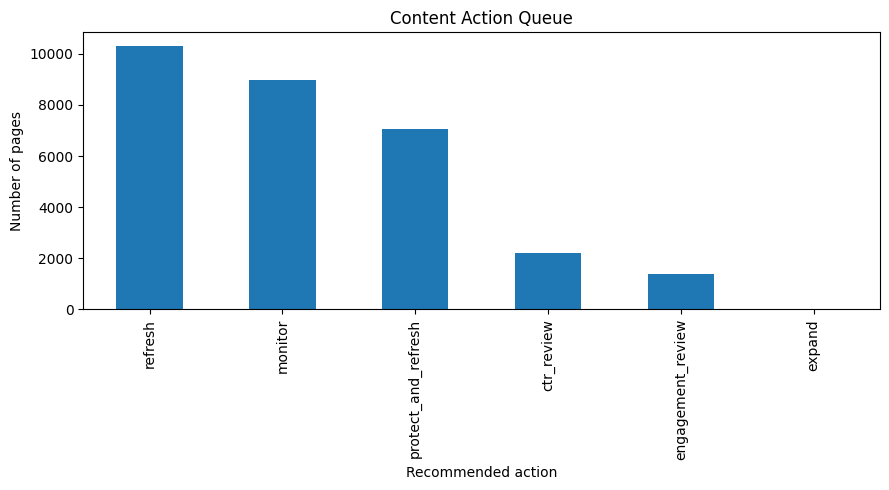

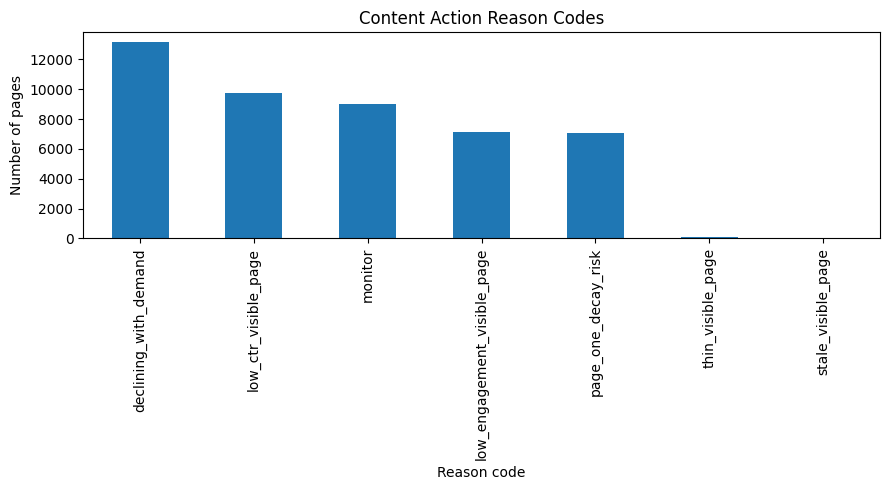


EXPORTS COMPLETE
Queue: C:\Users\Nayab\Desktop\FlyRank AI Internship\repo\work\outputs\content_action_queue.csv
Action figure: C:\Users\Nayab\Desktop\FlyRank AI Internship\repo\work\figures\content_action_distribution.png
Reason-code figure: C:\Users\Nayab\Desktop\FlyRank AI Internship\repo\work\figures\content_action_reason_codes.png
Model card: C:\Users\Nayab\Desktop\FlyRank AI Internship\repo\work\outputs\content_action_model_card.json


In [5]:
# ============================================================
# 5. EXPORTS FOR THE PAPER
# ============================================================

# REASONING:
# The assignment requires the ranked queue and reusable figures
# to be written to work/outputs/ or work/figures/.
#
# The queue is regenerated by this notebook and should remain
# outside Git if the repository leak guard blocks row-level data.
#
# The figures can be reused in the research paper.
#
# The exported model card records the intended use, limitations,
# human-review requirement and monitoring plan.


from pathlib import Path
import json
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent

OUTPUT_DIR = ROOT / "work" / "outputs"
FIGURE_DIR = ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# EXPORT RANKED QUEUE
# ------------------------------------------------------------

QUEUE_PATH = (
    OUTPUT_DIR
    / "content_action_queue.csv"
)

queue.to_csv(
    QUEUE_PATH,
    index=False
)

print(
    "Ranked queue exported to:"
)

print(QUEUE_PATH)


# ------------------------------------------------------------
# ACTION DISTRIBUTION FIGURE
# ------------------------------------------------------------

action_counts = (
    queue["recommended_action"]
    .value_counts()
)

plt.figure(
    figsize=(9, 5)
)

action_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Recommended action"
)

plt.ylabel(
    "Number of pages"
)

plt.title(
    "Content Action Queue"
)

plt.tight_layout()

ACTION_FIGURE = (
    FIGURE_DIR
    / "content_action_distribution.png"
)

plt.savefig(
    ACTION_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# REASON-CODE FIGURE
# ------------------------------------------------------------

reason_counts = (
    queue["reason_codes"]
    .str.split("|")
    .explode()
    .value_counts()
)

plt.figure(
    figsize=(9, 5)
)

reason_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Reason code"
)

plt.ylabel(
    "Number of pages"
)

plt.title(
    "Content Action Reason Codes"
)

plt.tight_layout()

REASON_FIGURE = (
    FIGURE_DIR
    / "content_action_reason_codes.png"
)

plt.savefig(
    REASON_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# MODEL / ACTION CARD
# ------------------------------------------------------------

model_card = {

    "lane":
        "Refresh / Content Opportunity Scoring",

    "purpose":
        "Rank pages for human review",

    "human_review_required":
        True,

    "automatic_publishing":
        False,

    "automatic_pruning":
        False,

    "automatic_url_merging":
        False,

    "causal_claims":
        False,

    "primary_limit":
        "A high score does not guarantee recovery after refresh.",

    "validation_scope":
        "Anonymized starter slice with client-holdout validation",

    "monitoring": [
        "Precision@20",
        "Precision@50",
        "Average precision",
        "Action distribution",
        "Reason-code distribution",
        "Feature distribution",
        "Human-review agreement",
        "Future-window validation"
    ]
}


CARD_PATH = (
    OUTPUT_DIR
    / "content_action_model_card.json"
)


with open(
    CARD_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_card,
        f,
        indent=2
    )


print("\n==========================================")
print("EXPORTS COMPLETE")
print("==========================================")

print(
    "Queue:",
    QUEUE_PATH
)

print(
    "Action figure:",
    ACTION_FIGURE
)

print(
    "Reason-code figure:",
    REASON_FIGURE
)

print(
    "Model card:",
    CARD_PATH
)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.